In [1]:
import pandas as pd
import category_encoders as ce
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import pickle


In [2]:
df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\crop_yield_dataset.csv")

df.head()
df.tail()
df.info()
df.describe()
df.columns.values
print(df["Soil Type"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature (°C)      1000 non-null   float64
 1   Rainfall (mm)         1000 non-null   float64
 2   Humidity (%)          1000 non-null   float64
 3   Soil Type             1000 non-null   object 
 4   Weather Condition     1000 non-null   object 
 5   Crop Type             1000 non-null   object 
 6   Yield (tons/hectare)  1000 non-null   float64
dtypes: float64(4), object(3)
memory usage: 54.8+ KB
Soil Type
Sandy    208
Loamy    204
Peaty    203
Clay     197
Silty    188
Name: count, dtype: int64


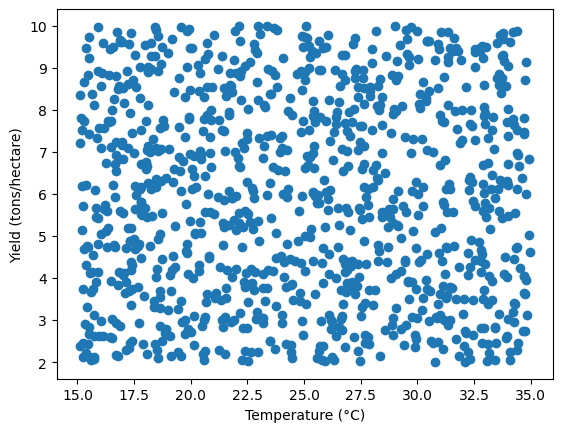

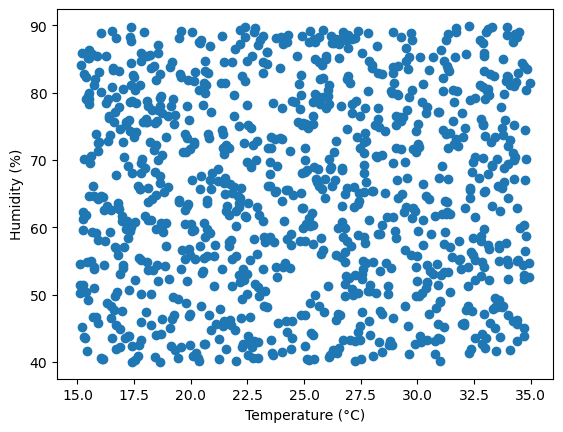

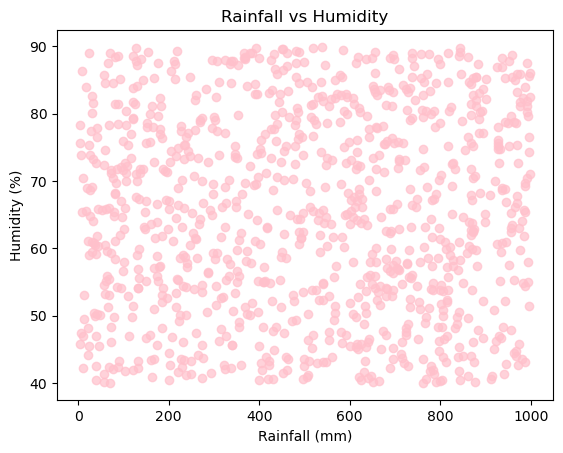

In [3]:
plt.scatter(df["Temperature (°C)"], df["Yield (tons/hectare)"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Yield (tons/hectare)")
plt.show()

plt.scatter(df["Temperature (°C)"], df["Humidity (%)"])
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.show()

plt.scatter(df["Rainfall (mm)"], df["Humidity (%)"], color="pink", alpha=0.7)
plt.xlabel("Rainfall (mm)")
plt.ylabel("Humidity (%)")
plt.title("Rainfall vs Humidity")
plt.show()


In [4]:
df = df.rename(columns={
    "Temperature (°C)": "temperature",
    "Rainfall (mm)": "rainfall",
    "Humidity (%)": "humidity",
    "Soil Type": "soil_type",
    "Weather Condition": "weather_condition",
    "Crop Type": "crop_type",
    "Yield (tons/hectare)": "yield"
})

df.columns


Index(['temperature', 'rainfall', 'humidity', 'soil_type', 'weather_condition',
       'crop_type', 'yield'],
      dtype='object')

In [5]:
x = df.drop("yield", axis=1)
y = df["yield"]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [6]:
X_train_ohe = pd.get_dummies(X_train, columns=["soil_type","weather_condition","crop_type"], drop_first=True)
X_test_ohe = pd.get_dummies(X_test, columns=["soil_type","weather_condition","crop_type"], drop_first=True)


In [7]:
looe_encoder = ce.LeaveOneOutEncoder(cols=["soil_type","weather_condition","crop_type"])

X_train_looe = looe_encoder.fit_transform(X_train, y_train)
X_test_looe = looe_encoder.transform(X_test)


In [8]:
with open("looe_encoder.pkl", "wb") as f:
    pickle.dump(looe_encoder, f)

with open("looe_encoder.pkl", "rb") as f:
    loaded_encoder = pickle.load(f)

loaded_encoder


,verbose,0
,cols,"['soil_type', 'weather_condition', ...]"
,drop_invariant,False
,return_df,True
,handle_unknown,'value'
,handle_missing,'value'
,random_state,None
,sigma,None


In [9]:
scaler_ohe = MinMaxScaler()
X_train_ohe_scaled = pd.DataFrame(scaler_ohe.fit_transform(X_train_ohe), columns=X_train_ohe.columns)
X_test_ohe_scaled = pd.DataFrame(scaler_ohe.transform(X_test_ohe), columns=X_test_ohe.columns)

print('Train shape:', X_train_ohe_scaled.shape)
print('Test shape:', X_test_ohe_scaled.shape)
X_train_ohe_scaled.head()


Train shape: (800, 14)
Test shape: (200, 14)


,temperature,rainfall,humidity,soil_type_Loamy,soil_type_Peaty,soil_type_Sandy,soil_type_Silty,weather_condition_Rainy,weather_condition_Stormy,weather_condition_Sunny,crop_type_Corn,crop_type_Rice,crop_type_Soybeans,crop_type_Wheat
0,0.042025,0.828851,0.656665,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.944777,0.119121,0.837728,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.608981,0.065202,0.520702,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.024270,0.409368,0.299902,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.914709,0.125354,0.997804,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [10]:
scaler_looe = MinMaxScaler()
X_train_looe_scaled = pd.DataFrame(scaler_looe.fit_transform(X_train_looe), columns=X_train_looe.columns)
X_test_looe_scaled = pd.DataFrame(scaler_looe.transform(X_test_looe), columns=X_test_looe.columns)

print('Train shape:', X_train_looe_scaled.shape)
print('Test shape:', X_test_looe_scaled.shape)
X_train_looe_scaled.head()


Train shape: (800, 6)
Test shape: (200, 6)


,temperature,rainfall,humidity,soil_type,weather_condition,crop_type
0,0.042025,0.828851,0.656665,0.789633,0.119398,0.941848
1,0.944777,0.119121,0.837728,0.865126,0.097366,0.577877
2,0.608981,0.065202,0.520702,0.032994,0.399405,0.937064
3,0.024270,0.409368,0.299902,0.975438,0.457937,0.982744
4,0.914709,0.125354,0.997804,0.873228,0.925252,0.028189


In [11]:
scaler_ohe_std = StandardScaler()
X_train_ohe_std_scaled = pd.DataFrame(scaler_ohe_std.fit_transform(X_train_ohe), columns=X_train_ohe.columns)
X_test_ohe_std_scaled = pd.DataFrame(scaler_ohe_std.transform(X_test_ohe), columns=X_test_ohe.columns)

print('Train shape:', X_train_ohe_std_scaled.shape)
print('Test shape:', X_test_ohe_std_scaled.shape)


Train shape: (800, 14)
Test shape: (200, 14)


In [12]:
scaler_looe_std = StandardScaler()
X_train_looe_std_scaled = pd.DataFrame(scaler_looe_std.fit_transform(X_train_looe), columns=X_train_looe.columns)
X_test_looe_std_scaled = pd.DataFrame(scaler_looe_std.transform(X_test_looe), columns=X_test_looe.columns)

print('Train shape:', X_train_looe_std_scaled.shape)
print('Test shape:', X_test_looe_std_scaled.shape)


Train shape: (800, 6)
Test shape: (200, 6)


In [13]:
final_train_ohe_mm = X_train_ohe_scaled.copy()
final_test_ohe_mm = X_test_ohe_scaled.copy()

final_train_ohe_mm["split"] = "train"
final_test_ohe_mm["split"] = "test"

final_ohe_mm = pd.concat([final_train_ohe_mm, final_test_ohe_mm])
final_ohe_mm.to_csv(r"C:\Users\LENOVO\OneDrive\Desktop\final_ohe_minmax.csv", index=False)

df_loaded = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\final_ohe_minmax.csv")
train_loaded_ohe_mm = df_loaded[df_loaded["split"]=="train"].drop(columns="split")
test_loaded_ohe_mm = df_loaded[df_loaded["split"]=="test"].drop(columns="split")


In [14]:
final_train_ohe_std = X_train_ohe_std_scaled.copy()
final_test_ohe_std = X_test_ohe_std_scaled.copy()

final_train_ohe_std["split"] = "train"
final_test_ohe_std["split"] = "test"

final_ohe_std = pd.concat([final_train_ohe_std, final_test_ohe_std])
final_ohe_std.to_csv(r"C:\Users\LENOVO\OneDrive\Desktop\final_ohe_standard.csv", index=False)

df_loaded = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\final_ohe_standard.csv")
train_loaded_ohe_std = df_loaded[df_loaded["split"]=="train"].drop(columns="split")
test_loaded_ohe_std = df_loaded[df_loaded["split"]=="test"].drop(columns="split")


In [15]:
final_train_looe_mm = X_train_looe_scaled.copy()
final_test_looe_mm = X_test_looe_scaled.copy()

final_train_looe_mm["split"] = "train"
final_test_looe_mm["split"] = "test"

final_looe_mm = pd.concat([final_train_looe_mm, final_test_looe_mm])
final_looe_mm.to_csv(r"C:\Users\LENOVO\OneDrive\Desktop\final_looe_minmax.csv", index=False)

df_loaded = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\final_looe_minmax.csv")
train_loaded_looe_mm = df_loaded[df_loaded["split"]=="train"].drop(columns="split")
test_loaded_looe_mm = df_loaded[df_loaded["split"]=="test"].drop(columns="split")


In [16]:
final_train_looe_std = X_train_looe_std_scaled.copy()
final_test_looe_std = X_test_looe_std_scaled.copy()

final_train_looe_std["split"] = "train"
final_test_looe_std["split"] = "test"

final_looe_std = pd.concat([final_train_looe_std, final_test_looe_std])
final_looe_std.to_csv(r"C:\Users\LENOVO\OneDrive\Desktop\final_looe_standard.csv", index=False)

df_loaded = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\final_looe_standard.csv")
train_loaded_looe_std = df_loaded[df_loaded["split"]=="train"].drop(columns="split")
test_loaded_looe_std = df_loaded[df_loaded["split"]=="test"].drop(columns="split")


In [17]:
# ================================================
# Save All Encoders and Scalers (Classification Project)
# ================================================
import pickle

# ---- LeaveOneOut Encoder ----
try:
    with open("looe_encoder.pkl", "wb") as f:
        pickle.dump(looe_encoder, f)   # Saves LeaveOneOut encoder
except NameError:
    print("⚠️ looe_encoder not found, skipping...")

# ---- Scalers for LeaveOneOut Encoded Data ----
try:
    with open("scaler_looe.pkl", "wb") as f:
        pickle.dump(scaler_looe, f)    # Saves MinMax/Standard Scaler after LOOE
except NameError:
    print("⚠️ scaler_looe not found, skipping...")

try:
    with open("scaler_looe_std.pkl", "wb") as f:
        pickle.dump(scaler_looe_std, f)  # Saves Standard Scaler for LOOE
except NameError:
    print("⚠️ scaler_looe_std not found, skipping...")

# ---- Scalers for OneHot Encoded Data ----
try:
    with open("scaler_ohe.pkl", "wb") as f:
        pickle.dump(scaler_ohe, f)     # Saves MinMax/Standard Scaler after OHE
except NameError:
    print("⚠️ scaler_ohe not found, skipping...")

try:
    with open("scaler_ohe_std.pkl", "wb") as f:
        pickle.dump(scaler_ohe_std, f)  # Saves Standard Scaler for OHE
except NameError:
    print("⚠️ scaler_ohe_std not found, skipping...")

# ---- Optional: Standalone Scalers (if separately used) ----
try:
    with open("standard_scaler.pkl", "wb") as f:
        pickle.dump(standard_scaler, f)  
except NameError:
    print("⚠️ standard_scaler not found, skipping...")

try:
    with open("minmax_scaler.pkl", "wb") as f:
        pickle.dump(minmax_scaler, f)    
except NameError:
    print("⚠️ minmax_scaler not found, skipping...")


⚠️ standard_scaler not found, skipping...
⚠️ minmax_scaler not found, skipping...


In [18]:
print("Shape of final dataset:", df_loaded.shape)
print("First 5 rows:")
print(df_loaded.head())


Shape of final dataset: (1000, 7)
First 5 rows:
   temperature  rainfall  humidity  soil_type  weather_condition  crop_type  \
0    -1.534059  1.077829  0.507474   0.362053          -0.794651   1.475689   
1     1.536054 -1.345349  1.129535   0.600741          -0.857644   0.209561   
2     0.394066 -1.529440  0.040357  -2.030255           0.005926   1.459046   
3    -1.594441 -0.354381 -0.718223   0.949523           0.173278   1.617951   
4     1.433799 -1.324067  1.679497   0.626360           1.509395  -1.702609   

   split  
0  train  
1  train  
2  train  
3  train  
4  train  


In [19]:
import pandas as pd

df_loaded = pd.read_csv("C:\\Users\\LENOVO\\OneDrive\\Desktop\\final_looe_standard.csv")


df_loaded.to_csv("C:\\Users\\LENOVO\\OneDrive\\Desktop\\view_dataset.csv", index=False)
print("✅ Dataset exported, open it from Desktop to see full data in Excel.")


✅ Dataset exported, open it from Desktop to see full data in Excel.


In [20]:
import pandas as pd

df = pd.read_csv("datasets/AgriYield/final_looe_standard.csv")
print(df.columns.tolist())


['temperature', 'rainfall', 'humidity', 'soil_type', 'weather_condition', 'crop type', 'split']


In [21]:
train_loaded_df = train_loaded_looe_std
test_loaded_df = test_loaded_looe_std


In [22]:
import pandas as pd
df_original = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\crop_yield_dataset.csv")
y = df_original["Yield (tons/hectare)"]  

In [23]:
X = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\final_looe_standard.csv")


In [24]:
train_X = X[X["split"] == "train"].drop(columns="split")
test_X  = X[X["split"] == "test"].drop(columns="split")

train_y = y[:len(train_X)]
test_y  = y[len(train_X):]


In [25]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model = RandomForestRegressor(n_estimators=100, random_state=42, criterion="squared_error")
model.fit(train_X, train_y)

preds = model.predict(test_X)
mse = mean_squared_error(test_y, preds)
print("Test MSE:", mse)


Test MSE: 5.5649090821264515


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

# 1. Linear Regression
lr = LinearRegression()
lr.fit(train_X, train_y)
pred_lr = lr.predict(test_X)
print("Linear Regression MSE:", mean_squared_error(test_y, pred_lr))

# 2. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(train_X, train_y)
pred_dt = dt.predict(test_X)
print("Decision Tree MSE:", mean_squared_error(test_y, pred_dt))

# 3. Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(train_X, train_y)
pred_gbr = gbr.predict(test_X)
print("Gradient Boosting MSE:", mean_squared_error(test_y, pred_gbr))


Linear Regression MSE: 5.457747992014647
Decision Tree MSE: 11.444482015743452
Gradient Boosting MSE: 5.696180754932725


In [27]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# 1. Linear Regression
lr = LinearRegression()
lr.fit(train_X, train_y)
pred_lr = lr.predict(test_X)
print("Linear Regression MSE:", mean_squared_error(test_y, pred_lr))

# 2. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(train_X, train_y)
pred_dt = dt.predict(test_X)
print("Decision Tree MSE:", mean_squared_error(test_y, pred_dt))

# 3. Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(train_X, train_y)
pred_gbr = gbr.predict(test_X)
print("Gradient Boosting MSE:", mean_squared_error(test_y, pred_gbr))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_X, train_y)
pred_rf = rf.predict(test_X)
print("Random Forest MSE:", mean_squared_error(test_y, pred_rf))

# 5. XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42, objective="reg:squarederror")
xgb.fit(train_X, train_y)
pred_xgb = xgb.predict(test_X)
print("XGBoost MSE:", mean_squared_error(test_y, pred_xgb))

# 6. AdaBoost
ada = AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(train_X, train_y)
pred_ada = ada.predict(test_X)
print("AdaBoost MSE:", mean_squared_error(test_y, pred_ada))




Linear Regression MSE: 5.457747992014647
Decision Tree MSE: 11.444482015743452
Gradient Boosting MSE: 5.696180754932725
Random Forest MSE: 5.5649090821264515
XGBoost MSE: 6.681518492624702
AdaBoost MSE: 5.467898271338436


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# 1. Linear Regression
lr = LinearRegression()
lr.fit(train_X, train_y)
pred_lr = lr.predict(test_X)
print("Linear Regression MSE:", mean_squared_error(test_y, pred_lr))

# 2. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(train_X, train_y)
pred_dt = dt.predict(test_X)
print("Decision Tree MSE:", mean_squared_error(test_y, pred_dt))

# 3. Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(train_X, train_y)
pred_gbr = gbr.predict(test_X)
print("Gradient Boosting MSE:", mean_squared_error(test_y, pred_gbr))

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(train_X, train_y)
pred_rf = rf.predict(test_X)
print("Random Forest MSE:", mean_squared_error(test_y, pred_rf))

# 5. XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42, objective="reg:squarederror")
xgb.fit(train_X, train_y)
pred_xgb = xgb.predict(test_X)
print("XGBoost MSE:", mean_squared_error(test_y, pred_xgb))

# 6. AdaBoost
ada = AdaBoostRegressor(n_estimators=100, random_state=42)
ada.fit(train_X, train_y)
pred_ada = ada.predict(test_X)
print("AdaBoost MSE:", mean_squared_error(test_y, pred_ada)) 

Linear Regression MSE: 5.457747992014647
Decision Tree MSE: 11.444482015743452
Gradient Boosting MSE: 5.696180754932725
Random Forest MSE: 5.5649090821264515
XGBoost MSE: 6.681518492624702
AdaBoost MSE: 5.467898271338436


In [40]:
sample = pd.DataFrame([{
    'temperature': 28,
    'rainfall': 120,
    'humidity': 70,
    'soil_type': 'clay',
    'weather_condition': 'sunny',
    'crop_type': 'rice'   # correct: underscore (_) use cheyyali
}])


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [42]:
categorical_features=["soil_type","weather_condition","crop_type"]
numeric_features=["temperature","rainfall","humidity"]

In [43]:
preprocessor=ColumnTransformer(transformers=[
    ("encode",OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False),categorical_features),
    ("scale",MinMaxScaler(),numeric_features)
])

In [44]:
pipeline=Pipeline(steps=[
    ("preprocessor",preprocessor),
    ("model",RandomForestRegressor(n_estimators=100,random_state=42,criterion="squared_error"))
])


In [45]:
pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encode', ...), ('scale', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
print("Predicted Crop:", pipeline.predict(sample)[0])


Predicted Crop: 6.355213300156083


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [38]:
print(sample.columns)
print(final_train_looe_std.columns)


Index(['temperature', 'rainfall', 'humidity', 'soil_type', 'weather_condition',
       'crop type'],
      dtype='object')
Index(['temperature', 'rainfall', 'humidity', 'soil_type', 'weather_condition',
       'crop_type', 'split'],
      dtype='object')


In [47]:
with open("pipeline.pkl","wb") as f:
    pickle.dump(pipeline,f)

In [49]:
# Drop "split" column if it exists in X_train or X_test
if "split" in X_train.columns:
    X_train = X_train.drop(columns=["split"])
if "split" in X_test.columns:
    X_test = X_test.drop(columns=["split"])

# Now get categorical and numeric columns
categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(exclude=['object']).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Predictions
y_pred = pipeline.predict(X_test)

# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R² Score: -0.02753523416898962
MSE: 5.1972956067124985


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Dataset
df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\crop_yield_dataset.csv")

# Rename for consistency
df = df.rename(columns={
    "Temperature (°C)": "temperature",
    "Rainfall (mm)": "rainfall",
    "Humidity (%)": "humidity",
    "Soil Type": "soil_type",
    "Weather Condition": "weather_condition",
    "Crop Type": "crop_type",
    "Yield (tons/hectare)": "yield"
})

X = df.drop("yield", axis=1)
y = df["yield"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing
categorical_cols = ["soil_type", "weather_condition", "crop_type"]
numeric_cols = ["temperature", "rainfall", "humidity"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Best model (example: Random Forest)
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R² Score: -0.02753523416898962
MSE: 5.1972956067124985
